# IMPORT AND SETUP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

# DATA PREPARATION

In [3]:
df = pd.read_csv('customer_segmentation.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Age Group,Estimated Savings (k$),Credit Score,Loyalty Years,Preferred Category
0,1,Male,19,15,39,18-25,11.10,456,3,Budget
1,2,Male,21,15,81,18-25,6.90,300,6,Luxury
2,3,Female,20,16,6,18-25,15.36,594,2,Budget
3,4,Female,23,16,77,18-25,7.79,300,6,Luxury
4,5,Female,31,17,40,26-35,12.47,480,5,Budget


In [4]:
print('The dataset is composed by', df.shape)

The dataset is composed by (200, 10)


In [5]:
df.dtypes

CustomerID                  int64
Gender                     object
Age                         int64
Annual Income (k$)          int64
Spending Score (1-100)      int64
Age Group                  object
Estimated Savings (k$)    float64
Credit Score                int64
Loyalty Years               int64
Preferred Category         object
dtype: object

# DATA CLEANING

In [6]:
print('The number of duplicated values is', df.duplicated().sum())

The number of duplicated values is 0


In [7]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Age Group                 4
Estimated Savings (k$)    0
Credit Score              0
Loyalty Years             0
Preferred Category        0
dtype: int64

In [8]:
df = df.dropna()
df.shape

(196, 10)

In [9]:
'''
There aren't duplicated values but four null observations were present, so I removed them.
'''

"\nThere aren't duplicated values but four null observations were present, so I removed them.\n"

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              196 non-null    int64  
 1   Gender                  196 non-null    object 
 2   Age                     196 non-null    int64  
 3   Annual Income (k$)      196 non-null    int64  
 4   Spending Score (1-100)  196 non-null    int64  
 5   Age Group               196 non-null    object 
 6   Estimated Savings (k$)  196 non-null    float64
 7   Credit Score            196 non-null    int64  
 8   Loyalty Years           196 non-null    int64  
 9   Preferred Category      196 non-null    object 
dtypes: float64(1), int64(6), object(3)
memory usage: 16.8+ KB


In [11]:
df.rename(columns = {'Annual Income (k$)': 'Annual Income', 'Spending Score (1-100)': 'Spending Score', 'Estimated Savings (k$)': 'Estimated Savings'}, inplace = True)

# EXPLORATORY DATA ANALYSIS

<Figure size 1600x400 with 0 Axes>

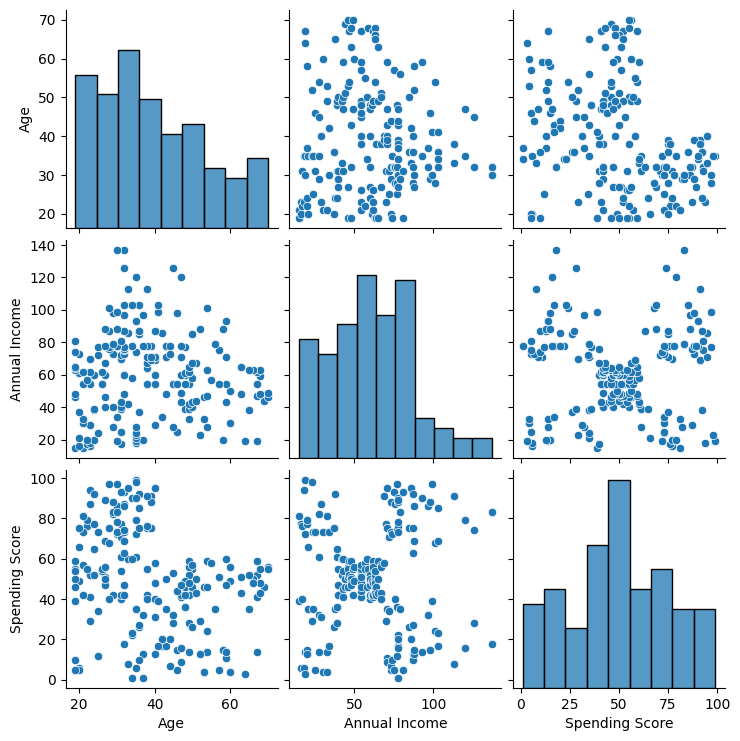

In [12]:
plt.figure(figsize=(16,4))

sns.pairplot(df[['Age', 'Annual Income', 'Spending Score']])

plt.show()

In [13]:
# Potentially, these graphs reveal numerous groups of customers but it should be analyzed more in detail

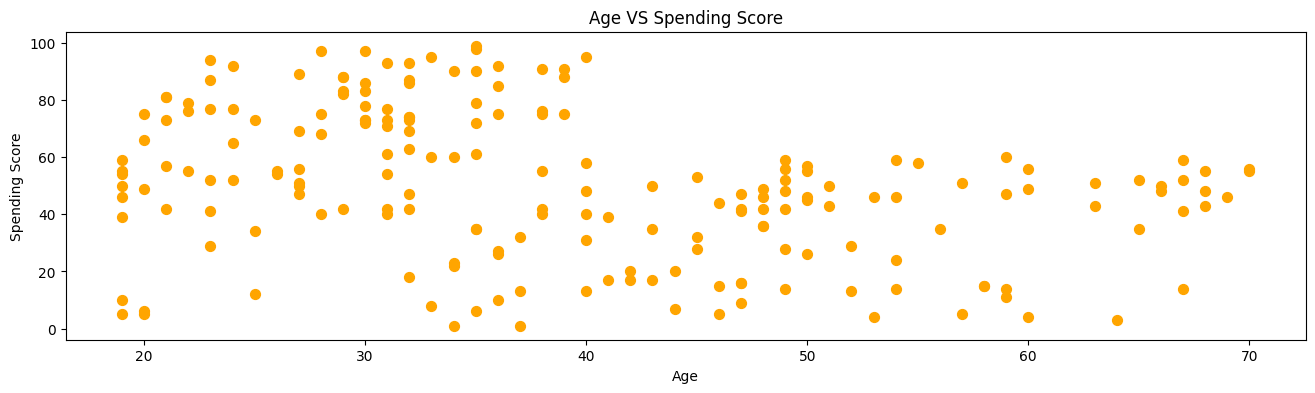

In [14]:
plt.figure(figsize=(16,4))

plt.scatter(df['Age'], df['Spending Score'], s = 50, color = 'orange')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Age VS Spending Score')

plt.show()

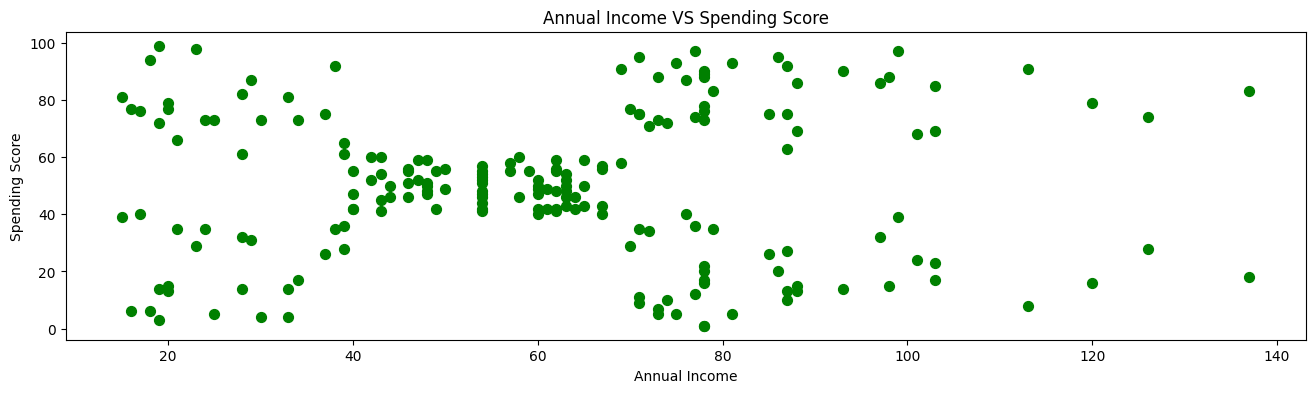

In [15]:
plt.figure(figsize=(16,4))

plt.scatter(df['Annual Income'], df['Spending Score'], s = 50, color = 'green')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Annual Income VS Spending Score')

plt.show()

In [16]:
# We don't need to preprocess categorical features, as only three numerical variables are used to deploy the algorithmic model

# BUILDING THE MODEL

## AGE VS SPENDING SCORE

In [17]:
from sklearn.cluster import KMeans

X = df[['Age', 'Spending Score']]

# Within-Cluster Sum of Squares - Empty List
wcss = []

# A loop is run in order to find the optimal number of customer groups
for i in range (1, 11):
    kmeans = KMeans(n_clusters = i, init = "k-means++", n_init = 10,  max_iter = 300, random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# init: parameter used to identify centroids or central points in each cluster. k-means++ is just a common choice for better performance
# max_iter: if the model doesn't converge before reaching 300 iterations, the model will stop working
# n_init: number of times the algorithm is running with different initializations
# random_state: seed generator of results, such that they are always reproducable in a pre-determined way.

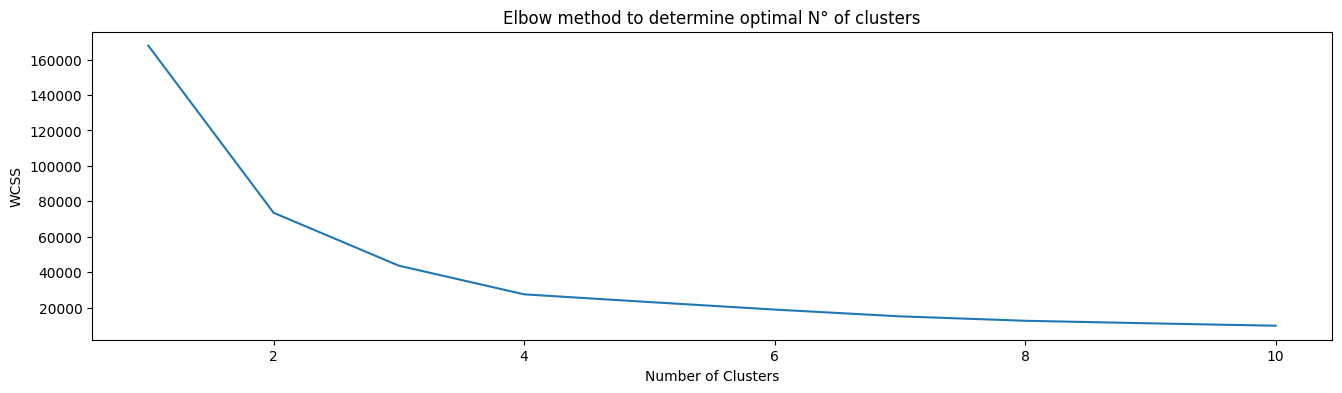

In [18]:
plt.figure(figsize=(16,4))

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow method to determine optimal N° of clusters')

plt.show()

In [19]:
kmeans = KMeans(n_clusters = 4, init = "k-means++", n_init = 10,  max_iter = 300, random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [20]:
df['Age Cluster'] = y_kmeans

In [21]:
df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score,Age Group,Estimated Savings,Credit Score,Loyalty Years,Preferred Category,Age Cluster
0,1,Male,19,15,39,18-25,11.10,456,3,Budget,0
1,2,Male,21,15,81,18-25,6.90,300,6,Luxury,2
2,3,Female,20,16,6,18-25,15.36,594,2,Budget,1
3,4,Female,23,16,77,18-25,7.79,300,6,Luxury,2
4,5,Female,31,17,40,26-35,12.47,480,5,Budget,0


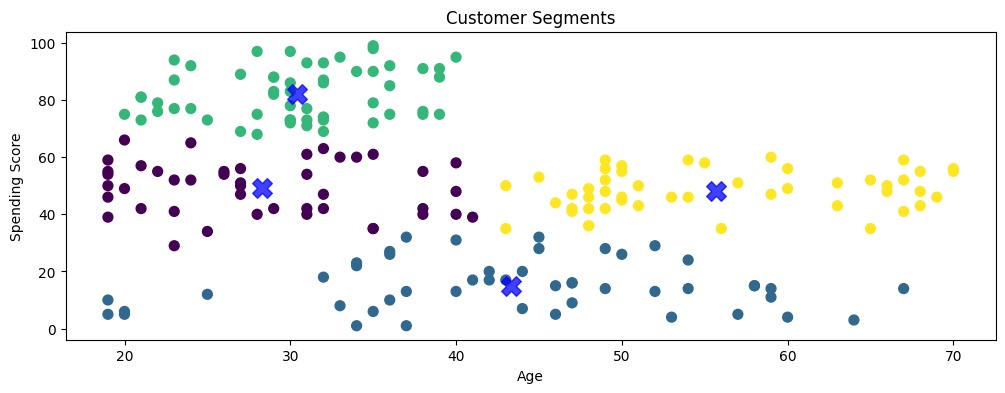

In [22]:
plt.figure(figsize=(12,4))

plt.scatter(X.iloc[:,0], X.iloc[:,1], c = y_kmeans, s = 50, cmap = 'viridis') # c colors the points based on the clusters assigned by K-Means.
centers = kmeans.cluster_centers_ # Memorizes central points coordinates of each group calculated by K-Means model
plt.scatter(centers[:,0], centers[:,1], c = 'blue', s = 200, alpha = 0.75, marker = 'X') # c transforms each marker 'X' of color blue, s are the dimension of points.
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Customer Segments')

plt.show()

# X.iloc[:,0]: takes the 1°column of table X (Age). X.iloc[:,1]: takes the 2°column of table X (Age) (Spending score).

# OBSERVATION

In [23]:
# 1) 20-40 years old customers who are moderate spenders
# 2) 20-40 years old customers who are high spenders
# 3) Wide age customer group who are low spenders
# 4) Middle-aged and old customers who are moderate spenders

# RESULTS AND BUSINESS RECOMMENDATIONS

In [24]:
# Younger customers tend to overspend based on their budget, they are the most valuable and are more likely to respond to premium promotions
# Mature customers should require different retention strategies in order not to lose them

## ANNUAL INCOME VS SPENDING SCORE

In [25]:
X = df[['Annual Income', 'Spending Score']]
wcss = []

for i in range (1, 11):
    kmeans = KMeans(n_clusters = i, init = "k-means++", n_init = 10,  max_iter = 300, random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

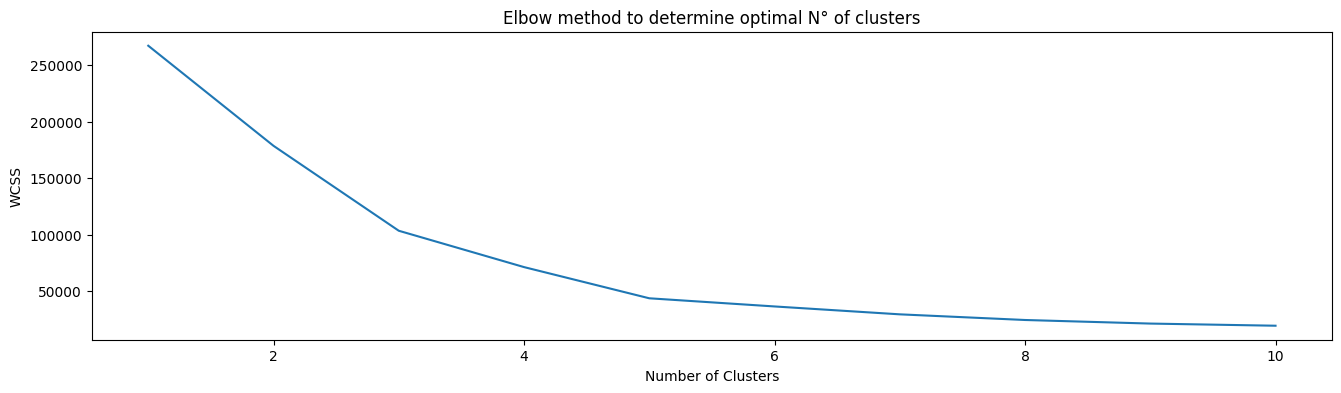

In [26]:
plt.figure(figsize=(16,4))

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow method to determine optimal N° of clusters')

plt.show()

In [27]:
kmeans = KMeans(n_clusters = 5, init = "k-means++", n_init = 10,  max_iter = 300, random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [28]:
df['Yearly Income Cluster'] = y_kmeans

In [29]:
df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score,Age Group,Estimated Savings,Credit Score,Loyalty Years,Preferred Category,Age Cluster,Yearly Income Cluster
0,1,Male,19,15,39,18-25,11.10,456,3,Budget,0,3
1,2,Male,21,15,81,18-25,6.90,300,6,Luxury,2,2
2,3,Female,20,16,6,18-25,15.36,594,2,Budget,1,3
3,4,Female,23,16,77,18-25,7.79,300,6,Luxury,2,2
4,5,Female,31,17,40,26-35,12.47,480,5,Budget,0,3


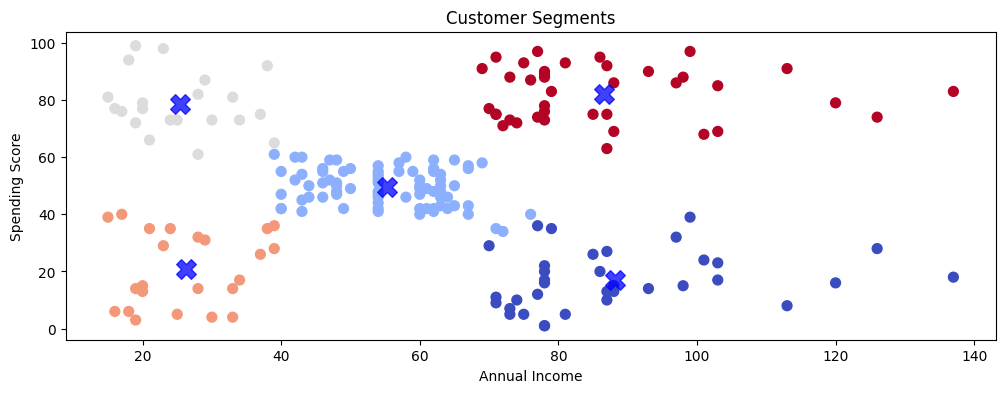

In [30]:
plt.figure(figsize=(12,4))

plt.scatter(X.iloc[:,0], X.iloc[:,1], c = y_kmeans, s = 50, cmap = 'coolwarm') 
centers = kmeans.cluster_centers_ 
plt.scatter(centers[:,0], centers[:,1], c = 'blue', s = 200, alpha = 0.75, marker = 'X') 
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')

plt.show()

# OBSERVATION

In [31]:
# 1) Low Income-Low Spenders 
# 2) Low Income-High Spenders 
# 3) Moderate Income-Moderate Spenders 
# 4) High Income-Low Spenders 
# 4) High Income-High Spenders 

# RESULTS AND BUSINESS RECOMMENDATIONS

In [32]:
# - The 1° group are budget-conscious or infrequent shoppers 
# - The 2° group are individuals who prioritize spending only for important occasions despite having a very low income
# - The 3° group is not critical, they just have a balanced spending habits
# - The 4° group probably save money or shop somewhere else
# - The 5° group are the premium customers who are more frequent shoppers and more likely to buy luxury products

In [33]:
# The VIP customers must keep going to have priority or early access on the last products on sale
# Special discount promotions for budget-conscious households can be targeted to cluster 1
# For cluster 4, the purpose is to investigate why they spend few. The solution is to conduct surveys to know their money habits, how do they save, invest, spend and finally knowing their shopping preferences in order to conduct specific retention strategies